# Thí nghiệm 3: Đánh giá mô hình bằng Cross-Validation
## Mục tiêu: so sánh độ ổn định của Single Split với K-Fold CV

### Bối cảnh thực tế
- Bài toán: dự đoán nhãn phân loại (mua/không mua)
- Câu hỏi: **độ chính xác đang thấy có thực sự ổn định không, hay chỉ là may mắn do cách chia dữ liệu?**

### So sánh phương pháp
- **Single train-test split (baseline)**: nhanh nhưng variance cao theo random seed
- **K-Fold Cross Validation (resampling)**: ổn định hơn vì đánh giá qua nhiều cách chia

### Metric theo dõi
- Mean accuracy
- Độ lệch chuẩn accuracy (accuracy variance)

### Kỳ vọng
- Single split dao động lớn hơn
- K-Fold CV cho ước lượng tổng quát hóa đáng tin hơn

### Dataset: Chi tiết các cột

| Cột | Kiểu | Ý nghĩa | Ghi chú |
|---|---|---|---|
| `age` | int | Tuổi khách hàng | Đặc trưng nhân khẩu học cơ bản |
| `job` | str | Nghề nghiệp | Ví dụ: admin, technician, services... |
| `marital` | str | Tình trạng hôn nhân | married, single, divorced |
| `education` | str | Trình độ học vấn | primary, secondary, tertiary |
| `balance` | float | Số dư tài khoản | Đặc trưng tài chính quan trọng |
| `housing` | str | Có khoản vay mua nhà không | yes/no |
| `loan` | str | Có khoản vay cá nhân không | yes/no |
| **`y`** | **str** | **Nhãn mục tiêu: có đăng ký sản phẩm hay không** | **⭐ Biến mục tiêu cho bài toán classification** |

### Tại sao chọn dataset này?
- ✅ Bài toán phân loại nhị phân rõ ràng, phù hợp cho model selection
- ✅ Dữ liệu thực tế thường nhiễu, giúp thấy rõ độ dao động của single split
- ✅ Kích thước dữ liệu đủ để minh họa lợi ích của K-Fold CV
- ✅ Có ý nghĩa ứng dụng thực tế trong marketing và dự đoán hành vi khách hàng

In [10]:
# Bước 1: Chuẩn bị dataset (bank.csv)
# - Ưu tiên dùng gdown để đồng bộ với notebook 1
# - Nếu gdown không khả dụng hoặc link lỗi, fallback về requests

import os, sys, requests

if 'google.colab' in sys.modules:
    data_dir = '/content/data'
else:
    data_dir = os.path.abspath('../data') if os.path.exists('../data') else os.path.abspath('data')
os.makedirs(data_dir, exist_ok=True)

path = os.path.join(data_dir, 'bank.csv')

if not os.path.exists(path):
    try:
        import importlib
        gdown = importlib.import_module('gdown')
        # Bạn có thể thay ID này bằng file bank.csv trên Google Drive của riêng bạn
        gdrive_id = '1gRghn3BMMv5maHRfFstpAFCaqzSmOLyx'
        url = f'https://drive.google.com/uc?id={gdrive_id}'
        print(f'⏳ Downloading from Google Drive: {url}')
        gdown.download(url, path, quiet=False)
        print(f'✅ Downloaded by gdown: {path}')
    except Exception as e:
        print(f'⚠️ Gdown failed ({e}). Fallback sang GitHub raw...')
        raw_url = 'https://raw.githubusercontent.com/sharmaroshan/Clustering-Bank-Marketing-Dataset/master/bank.csv'
        r = requests.get(raw_url, timeout=30)
        r.raise_for_status()
        with open(path, 'wb') as f:
            f.write(r.content)
        print(f'✅ Downloaded by requests fallback: {path}')
else:
    print(f'✅ File already exists: {path}')

✅ File already exists: /content/data/bank.csv


In [11]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

def compare_stability(model, X, y, n_trials=50):
    """
    So sánh độ ổn định của 2 quy trình đánh giá mô hình:
    1) Single train-test split lặp lại nhiều lần
    2) K-Fold Cross Validation
    """
    single_scores = []
    for i in range(n_trials):
        # Mỗi trial dùng một random_state khác nhau để đo mức dao động
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
        
        # Huấn luyện trên train và đo accuracy trên test
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        single_scores.append(score)
    
    # K-Fold CV: ít phụ thuộc vào một cách chia dữ liệu cụ thể
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=kf)
    
    return single_scores, cv_scores

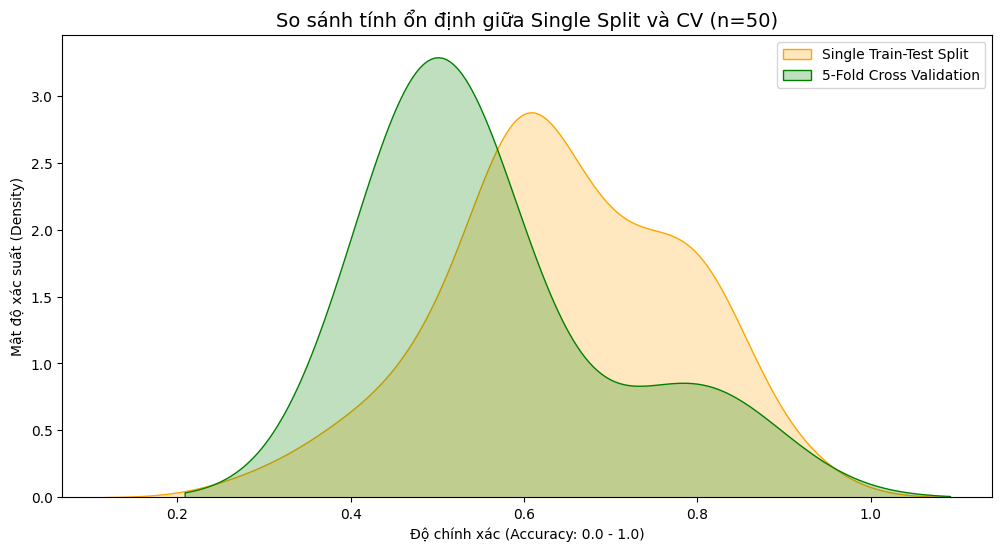

📊 Stability summary:
Sample size n = 50
Độ lệch chuẩn Single Split: 0.1329
Độ lệch chuẩn K-Fold CV: 0.1200
Mean accuracy Single Split: 0.6440
Mean accuracy K-Fold CV: 0.5600


In [12]:
# Bước 2: Sinh dữ liệu classification và chạy so sánh stability
# - Dùng n=50 giống thí nghiệm 1 để thống nhất cách trình bày

n = 50
X, y = make_classification(
    n_samples=n,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    random_state=42
)
model = DecisionTreeClassifier(max_depth=5, random_state=42)

s, c = compare_stability(model, X, y)

# Trực quan hóa phân phối accuracy của hai cách đánh giá
plt.figure(figsize=(12, 6))
sns.kdeplot(s, label='Single Train-Test Split', fill=True, color='orange')
sns.kdeplot(c, label='5-Fold Cross Validation', fill=True, color='green')

plt.title('So sánh tính ổn định giữa Single Split và CV (n=50)', fontsize=14)
plt.xlabel('Độ chính xác (Accuracy: 0.0 - 1.0)')
plt.ylabel('Mật độ xác suất (Density)')
plt.legend()
plt.show()

print('📊 Stability summary:')
print(f"Sample size n = {n}")
print(f"Độ lệch chuẩn Single Split: {np.std(s):.4f}")
print(f"Độ lệch chuẩn K-Fold CV: {np.std(c):.4f}")
print(f"Mean accuracy Single Split: {np.mean(s):.4f}")
print(f"Mean accuracy K-Fold CV: {np.mean(c):.4f}")

## 3.3 Nhận xét kết quả

- Nếu độ lệch chuẩn của Single Split lớn hơn K-Fold CV: đúng với kỳ vọng rằng một lần chia dữ liệu dễ gây kết luận thiếu ổn định.
- Nếu mean accuracy của hai phương pháp gần nhau nhưng variance khác nhau: CV vẫn nên được ưu tiên vì độ tin cậy cao hơn.
- Ý nghĩa thực tế: khi chọn mô hình cho triển khai, **độ ổn định quan trọng không kém điểm số trung bình**.
- Kết luận phương pháp: trong bối cảnh model selection, **Cross-Validation là lựa chọn mặc định an toàn hơn** so với chỉ báo cáo một lần train-test split.